# Lab 5: Gravity Modeling and Survey Design
------------------
* **Lab session:** Tuesday, September 29, 2026 (Parts 1 to 5)
* **Tunnel tour:** Tuesday, October 6, 2026 (Part 6)
* **Due date:** Tuesday, October 13, 2026, 11:59 pm (same as Lab 6)

## Setup (note: only if needed)
If you get a `ModuleNotFoundError` or the widgets show a "Failed to load model class" message, remove the `#` from the line below and run the cell **once**. Then fully restart JupyterLab (File > Shut Down, then relaunch it) and run the notebook from the top. You only need to do this once per computer.

In [1]:
# %pip install ipycanvas ipyevents ipywidgets plotly anywidget

# Objectives
Over the next three labs, we'll try to detect the steam tunnel under Mines using a gravity survey. In reality, most surveys are  designed before we really know exactly what is happening underground, but we might have some ideas of what to expect to guide the design. This week you will do the same thing: model the tunnel using what we know (and don't know) about it and then design a survey that should detect it across that uncertainty and describe your predictions. On **October 6** we'll actually go into the tunnel and measure it and see which survey design you should use given it's real dimensions. Then on **October 20** we'll run the survey and find out how well our predictions (forward modeled responses) held up.

By the end of this lab you should be able to:
* Represent 2D bodies as polygons and forward model their gravity response
* Use superposition to model more than one body
* Explain how depth, size, and density contrast control the amplitude and width of an anomaly
* Design a survey (line length, station spacing, reading time) that is robust to uncertainty in the target
* Make testable, quantitative predictions

# Background

## 2D gravity modeling
In a 2D model every feature extends infinitely into and out of the page. We are going to model these objects as polygonal prisms with a constant density. This is a good approximation when the feature is long and straight compared with its depth (i.e. doesn't have a dip or change direction), which is true for a straight section of tunnel. These are all valid assumptions for a long straight section of our tunnel.

We use two tools in this notebook:
* `GravInteract` (from `grav_utils`): an interactive widget where you can drag polygons around and then watch how the gravity anomalies change.
* `gz_polygon()` (introduced in Part 3): computes the same thing without the widget, so you can compare many models at once.

**Coordinates:** `x` is distance along the profile (m) and `z` is elevation (m). The ground surface is `z = 0`, so anything underground has **negative** `z`.

## Density contrast (read this carefully)
Gravity responds to **density contrast**, Δρ = ρ(body) − ρ(host). For the tunnel:
* ρ(body) is essentially air, about 0.001 g/cc.
* ρ(host) is whatever surrounds the tunnel: fill, soil, and some concrete and pavement. This is **not** the 2.67 g/cc you use for the Bouguer correction. That value is a standard reference density for crustal rock, not a measured property of the dirt/alluvium/soil/fill under the Green Center sidewalk.

So a tunnel in 1.8 g/cc fill has Δρ ≈ −1.8 g/cc. 
**NOTE:** Part of this lab is deciding what range of host densities is reasonable.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grav_utils.grav_interact import GravInteract
from grav_utils.gpoly import gpoly

# Part 1: Warm-up with a dike

## Supplying locations
To model gravity (or really any geophysical data), we need to know where we want to calculate data. Below we create a set of x-locations along a line, with a specific station spacing from −2500 m to 2500 m along the profile with stations every 10 m, at 0 m elevation.

**note**: If you were wanting to model at real-world locations, you would likely read locations in from a data file.

In [3]:
xmin, xmax = -2500, 2500
dx = 10

obs_x = np.linspace(xmin, xmax, (xmax - xmin) // dx + 1)
obs_z = np.zeros_like(obs_x)
obs1 = np.c_[obs_x, obs_z]
obs1.shape

(501, 2)

## Modeling a Dike
Now let's define our dike:

In [4]:
# Corners of a vertical dike (x, z), in clockwise order
dike_v = np.array([
    [-150.0, -100.0],
    [150.0, -100.0],
    [150.0, -1200.0],
    [-150.0, -1200.0],
])

This is a simple interactive widget to model the gravity anomaly.
With it you can add polygons, change their position, add more points to the prism.

You can programmatrically add polygons to it using the
`set_polygons()` method.

You can also retrieve the polyons using the `get_polygons()` method.

Play around with this a bit, and answer some questions about the gravity data.

In [5]:
modeler = GravInteract(obs1)
modeler.set_polygons(dike_v)
modeler

GravInteract(children=(FigureWidget({
    'data': [{'mode': 'lines',
              'type': 'scatter',
        …

### Question 1
Play with the widget.
1. What happens to the anomaly when you move the dike deeper? Shallower? Describe **both** the amplitude and the width of the anomaly.
2. What happens to the anomaly when you increase the density contrast?
3. What changes to the anomaly when the density contrast goes from positive to negative?

### Question 2
At any positive density contrast, make the dike (1) dip to the right and (2) dip to the left. For each, include a plot of the anomaly, the polygon vertices (use `modeler.get_polygons()`), and the density contrast. How could you tell dip direction from the data alone?

**NOTE:** don't stress too much about being too verbose with your answers here, just try to concentrate on what is really happening to the curves when you move the anomalies. I want you to get a good 'feel' for what different subsurface anomalies do to the data we collect at the surface, not fret over the perfect answer. 

Also for your own use: You can also programatically retrieve the polyons using the get_polygons() method.

(In jupyterlab, the save polygons and load polygons buttons should also work to save/load it to a file --> see below)

In [6]:
modeler.get_polygons()

[array([[ -150.,  -100.],
        [  150.,  -100.],
        [  150., -1200.],
        [ -150., -1200.]])]

as well as the current data, if you wanted to plot it yourself in another way.

In [7]:
gz = modeler.get_data()

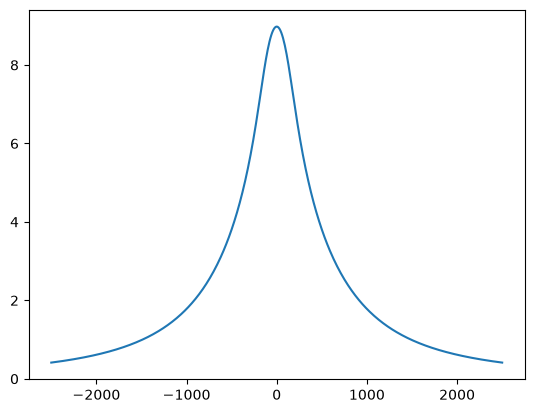

In [8]:
plt.plot(obs1[:, 0], gz)

## Superposition and sample spacing
As we discussed in class, gravity follows the superposition principle. For example, here are two dikes, both dipping in the same direction

To get the gravitational response of the two bodies, we can simply sum them together!

**_NOTE:_** You can pass multiple polygons to the `set_polygons()` function!

In [9]:
dike_v2 = dike_v + [1000, 50]

modeler2 = GravInteract(obs1)
modeler2.set_polygons([dike_v, dike_v2])
modeler2

GravInteract(children=(FigureWidget({
    'data': [{'mode': 'lines',
              'type': 'scatter',
        …

## Sample Spacing:
Next we're going to adjust the sample spacing and compare it to the image above with two dikes.

### Question 3
Start with a very coarse station spacing (such as the `dx = 1000` below) and decrease it until you would interpret the two dikes the same way as in the densely sampled model above. 

What spacing did you settle on, and how does it compare to the depth and width of the dikes?

Think about the rule of sample spacing discussed in class, how does your sample spacing compare?

In [10]:
dx = 50   # change me

obs_x2 = np.linspace(xmin, xmax, (xmax - xmin) // dx + 1)
obs2 = np.c_[obs_x2, np.zeros_like(obs_x2)]

# Again, starting another new widget with a different name so it doesn't clobber any others
modeler3 = GravInteract(obs2)
modeler3.set_polygons([dike_v, dike_v2])
modeler3

GravInteract(children=(FigureWidget({
    'data': [{'mode': 'lines',
              'type': 'scatter',
        …

# Part 2: Ready for the tunnel? Start with what we sort of know....

![Tunnel](resources/tunnel_cross.png)

**Figure 1**: Approximate cross-section of the Mines steam tunnels. Notice there are **two** tunnels, an upper and a lower one, and they are offset from each other. Our survey line crosses both, so our model needs two polygons, and their anomalies add together (superposition, just like the two dikes).

We have **not** measured this section of tunnel yet. Here are broad bounds:

| Parameter | Upper tunnel | Lower tunnel |
|---|---|---|
| Width (m) | 1.0 to 1.6 | 1.4 to 2.0 |
| Height (m) | 1.5 to 2.2 | 1.4 to 2.0 |
| Depth to roof (m) | 0.2 to 0.8 | 0.8 to 1.8 |
| Center position along the line (m) | fixed at 0 | 0.5 to 2.5 |

There are two things that we can't get from this figure: dimensions and densities. 
**Your first job is to try and determine the density of the material surounding the tunnels** or, at least, what that density does to our anomaly/uncertainty. 

### Question 4: What is the tunnel sitting in?
Do a little research and cite your sources (a textbook density table, a USGS map, a website is fine if you say which one).
1. What geologic material is under the Mines campus and specifically under sidewalk outside of the Green Center? (Hint: maybe look at the USGS geologic map of the Golden quadrangle.)
2. The tunnel was dug and then backfilled. What is typical *engineered backfill* made of, and how dense is it when compacted?
3. Give a density range (g/cc) for your host material both **dry** and **saturated**. Does it make much of a difference?
4. Choose a host density range for your model and justify it in one or two sentences.

### Question 5: Your best guess
Before you run any models, pick a best-guess value for each parameter in the table above (width, height, depth to roof, center position) and justify each in one sentence (for example: "people walk upright in it, so the height is probably at least ... m"). Include a labeled sketch of both tunnels with your numbers. **Do not change this answer after the tour.** I'm not going to grade you on how correct you are; I want to see reasoning! The whole point is to compare it with what we measure on October 6.

# Part 3: Modeling under uncertainty

## Two helper functions
The widget is great for exploring one model at a time. To compare many tunnels at once, we compute gravity directly with two small helpers:
* `box()` builds the corners of a rectangular tunnel from its center position, width, depth to roof, and height.
* `gz_polygon()` computes the gravity anomaly of a polygon. It calls `gpoly`, the same function the widget uses.

You do not need to edit this cell, just run it.

In [11]:
def gz_polygon(obs, verts, drho):
    '''
    Vertical gravity anomaly (mGal) of a 2D polygonal prism.
    obs   : (n, 2) array of (x, z) observation points, z = 0 at the surface
    verts : (m, 2) array of polygon vertices (x, z), z negative underground
    drho  : density contrast in g/cc
    '''
    # gpoly uses z positive down; our coordinates use z negative underground,
    # so flip the sign of the result (this is exactly what GravInteract does).
    return -gpoly(obs, verts, drho)


def box(x_center, width, depth_top, height):
    '''Rectangle vertices for a tunnel whose roof is depth_top meters below the surface.'''
    xl, xr = x_center - width / 2, x_center + width / 2
    zt, zb = -depth_top, -(depth_top + height)
    return np.array([[xl, zt], [xr, zt], [xr, zb], [xl, zb]])


def tunnels(p):
    '''Build both tunnel polygons and the density contrast from a parameter dictionary.'''
    polys = [box(p['upper_x'], p['upper_width'], p['upper_roof'], p['upper_height']),
             box(p['lower_x'], p['lower_width'], p['lower_roof'], p['lower_height'])]
    drho = 0.001 - p['host_density']   # air minus host
    return polys, drho


def model(p, obs):
    '''Gravity anomaly in µGal for a parameter dictionary.'''
    polys, drho = tunnels(p)
    return sum(gz_polygon(obs, poly, drho) for poly in polys) * 1000


def peak_and_width(x, g):
    '''Peak (most negative) anomaly and full width at half maximum.'''
    half = g.min() / 2
    inside = x[g <= half]
    return g.min(), inside.max() - inside.min()


x_fine = np.arange(-15, 15.01, 0.05)
obs_fine = np.c_[x_fine, np.zeros_like(x_fine)]

### Question 6: Model your best guess
Enter your best-guess values from Question 5 and your host density from Question 4 into the function below. Run the cell and include the figure in your answer. Where is the anomaly centered, and is it symmetric? Why or why not?

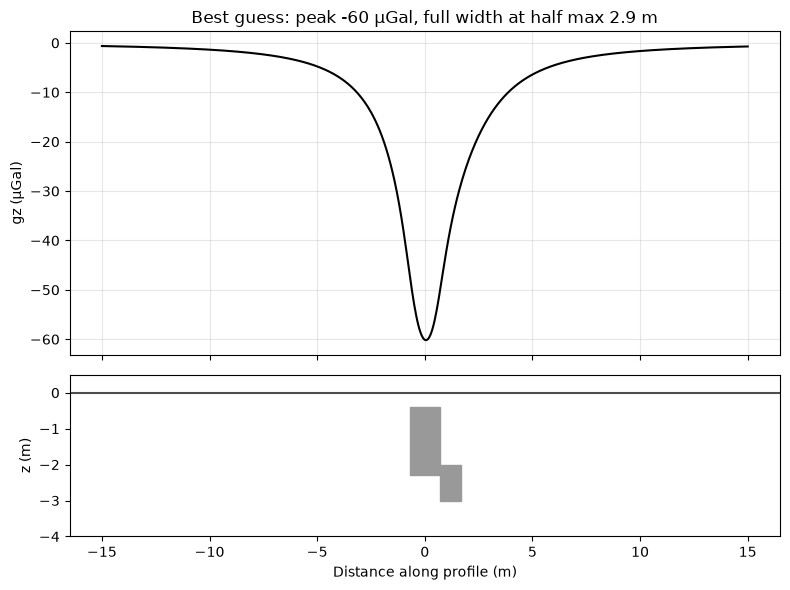

In [12]:
# ---- EDIT: your best guess (m and g/cc) ----
prior = {
    'upper_x': 0.0, 'upper_width': 1.4, 'upper_height': 1.9, 'upper_roof': 0.4,
    'lower_x': 1.2, 'lower_width': 1.0, 'lower_height': 1.0, 'lower_roof': 2.0,
    'host_density': 1.9,
}
# ---------------------------------------------

g_prior = model(prior, obs_fine)
pk, w = peak_and_width(x_fine, g_prior)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(x_fine, g_prior, 'k')
ax1.set_ylabel('gz (µGal)')
ax1.grid(alpha=0.3)
ax1.set_title(f'Best guess: peak {pk:.0f} µGal, full width at half max {w:.1f} m')
for poly in tunnels(prior)[0]:
    ax2.fill(poly[:, 0], poly[:, 1], color='0.6')
ax2.axhline(0, color='0.3')
ax2.set_ylim(-4, 0.5)
ax2.set_xlabel('Distance along profile (m)')
ax2.set_ylabel('z (m)')
plt.tight_layout()

If you want to drag the tunnels around, this loads your best guess into the widget. The widget's density slider starts at +1.0 g/cc, so we set it for you.

In [13]:
polys, drho = tunnels(prior)
modeler_tun = GravInteract(obs_fine)
modeler_tun.set_polygons(polys)
modeler_tun.set_density(drho)
modeler_tun

GravInteract(children=(FigureWidget({
    'data': [{'mode': 'lines',
              'type': 'scatter',
        …

### Question 7: Let's test which parameters actually matter?
The cell below takes your best guess at the tunnel(s) size and surrounding fill and changes **one parameter at a time** to the low and high end of its range, keeping everything else fixed. Edit the ranges to match Part 2 and your Question 4 density range.
1. Which parameter changes the **peak** the most? Which changes the **width** the most?
2. Which parameters barely matter? What does that tell you about what is worth measuring carefully on October 6 during the tunnel tour?
3. Why does a deeper tunnel produce a *wider* anomaly?
4. Could a deeper tunnel in denser fill give almost the same anomaly as a shallower tunnel in lighter fill? What does that mean for interpreting our data in late October?

     parameter | peak at low / high (µGal) | width at low / high (m)
  host_density |    -34.8 /    -82.4     |  2.85 /  2.85
    upper_roof |    -68.9 /    -23.2     |  2.35 /  7.65
   upper_width |    -48.1 /    -92.5     |  2.75 /  3.85
  upper_height |    -53.7 /    -64.4     |  2.70 /  2.95
   lower_width |    -63.5 /    -68.4     |  3.00 /  3.25
       lower_x |    -61.6 /    -57.0     |  2.75 /  2.85
  lower_height |    -63.0 /    -66.7     |  2.95 /  3.15
    lower_roof |    -63.2 /    -60.6     |  3.05 /  2.85


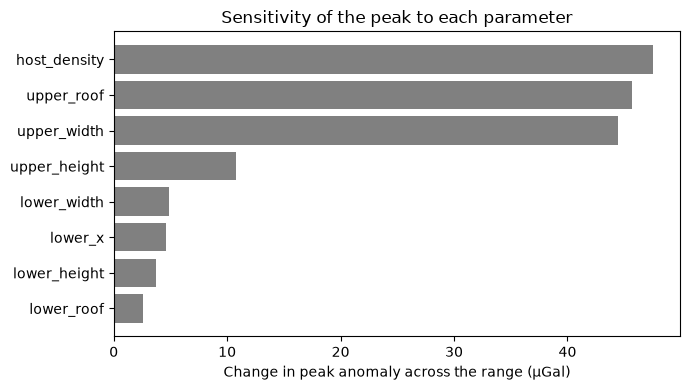

In [14]:
# ---- EDIT: (low, high) for each parameter ----
ranges = {
    'upper_width': (1.0, 3), 'upper_height': (1.5, 2.2), 'upper_roof': (0.2, 4),
    'lower_x': (0.5, 2.5), 'lower_width': (1.4, 2.0), 'lower_height': (1.4, 2.0),
    'lower_roof': (0.8, 1.8), 'host_density': (1.1, 2.6),
}
# ----------------------------------------------

rows = []
for name, (lo, hi) in ranges.items():
    out = []
    for val in (lo, hi):
        p = dict(prior, **{name: val})
        out.append(peak_and_width(x_fine, model(p, obs_fine)))
    rows.append((name, out[0][0], out[1][0], out[0][1], out[1][1]))

rows.sort(key=lambda r: -abs(r[2] - r[1]))
print(f"{'parameter':>14} | peak at low / high (µGal) | width at low / high (m)")
for r in rows:
    print(f"{r[0]:>14} | {r[1]:8.1f} / {r[2]:8.1f}     | {r[3]:5.2f} / {r[4]:5.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
names = [r[0] for r in rows][::-1]
ax.barh(names, [abs(r[2] - r[1]) for r in rows][::-1], color='0.5')
ax.set_xlabel('Change in peak anomaly across the range (µGal)')
ax.set_title('Sensitivity of the peak to each parameter')
plt.tight_layout()

### Question 8: Understanding the envelope of uncertainty
Now we'll combine the extremes. The cell below builds the **smallest and lowest density contrast** tunnel (every parameter pushed toward a smaller anomaly) and the **biggest, shallowest, highest contrast** tunnel (every parameter pushed toward a stronger anomaly). The real answer should fall somewhere in the gray band. How wide is the band, in µGal? Is it wider than you expected?

weak response: peak  -15.2 µGal, full width at half max 6.50 m
your best guess: peak  -60.2 µGal, full width at half max 2.85 m
strong response: peak -211.4 µGal, full width at half max 3.65 m


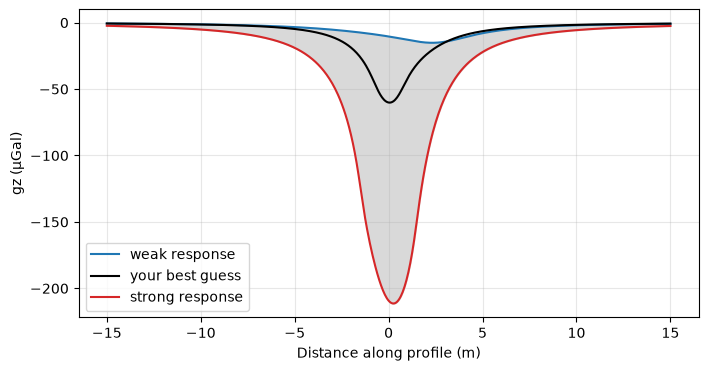

In [15]:
weak, strong = dict(prior), dict(prior)
for name, (lo, hi) in ranges.items():
    g_lo = model(dict(prior, **{name: lo}), obs_fine).min()
    g_hi = model(dict(prior, **{name: hi}), obs_fine).min()
    # more negative peak = stronger anomaly
    strong[name], weak[name] = (lo, hi) if g_lo < g_hi else (hi, lo)

cases = {'weak response': weak, 'your best guess': prior, 'strong response': strong}
colors = {'your best guess': 'k', 'weak response': 'tab:blue', 'strong response': 'tab:red'}
gz_fine = {k: model(p, obs_fine) for k, p in cases.items()}

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_fine, gz_fine['weak response'], gz_fine['strong response'], color='0.85')
for k, g in gz_fine.items():
    ax.plot(x_fine, g, color=colors[k], label=k)
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('gz (µGal)')
ax.legend()
ax.grid(alpha=0.3)

for k, g in gz_fine.items():
    pk, w = peak_and_width(x_fine, g)
    print(f"{k:>6}: peak {pk:6.1f} µGal, full width at half max {w:4.2f} m")

# Part 4: Survey design
The survey will run on **October 20** in a single 3-hour lab block. As you know, our gravimeters are Scintrex CG-5s. In the next two labs, you will confirm the dimensions of the tunnel so you can pick the ideal survey plan and also have a forward model to compare your gravimeter measurements to determine the general density of the fill surrounding the tunnel. 

### Question 9: Can we even see it?
Set `noise` to the station uncertainty you expect (maybe think of lab 4? but we're outside now... wind, but less building sway...). The plot shows where each case rises above the noise.
1. Is the `weak` case detectable? If not, what can you change (reading time, number of repeat readings, number of stations) to detect it?
2. How far from the tunnel does the `strong` case stay above the noise? Use this to choose your line length.

weak response: never above noise
your best guess: above noise from -1.55 to  1.90 m
strong response: above noise from -4.25 to  4.65 m


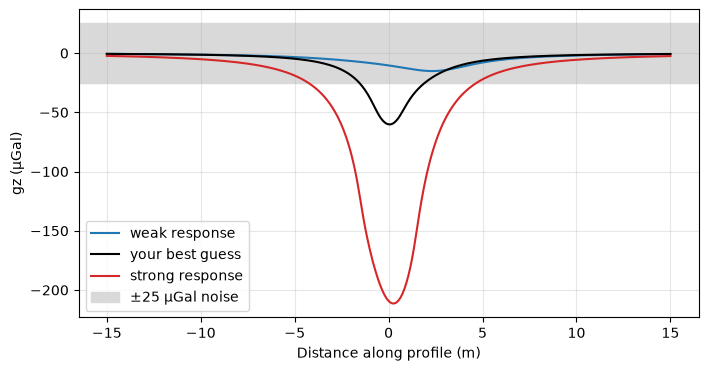

In [16]:
noise = 25  # µGal, EDIT ME

fig, ax = plt.subplots(figsize=(8, 4))
for k, g in gz_fine.items():
    ax.plot(x_fine, g, color=colors[k], label=k)
ax.axhspan(-noise, noise, color='0.85', label=f'±{noise} µGal noise')
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('gz (µGal)')
ax.legend()
ax.grid(alpha=0.3)

for k, g in gz_fine.items():
    above = x_fine[np.abs(g) > noise]
    if above.size:
        print(f"{k:>6}: above noise from {above.min():5.2f} to {above.max():5.2f} m")
    else:
        print(f"{k:>6}: never above noise")

### Question 10: Station spacing
Design a station layout below. You may use uniform spacing or a variable spacing that is denser near the tunnels. Your layout should resolve the anomaly shape for **all three** (i.e. worst, your most realistic case, and best case scenario) cases. Remember the lower tunnel is offset, so the anomaly may not be centered on 0.
1. Report your line length, spacing(s), and total number of stations.
2. Justify your spacing using the anomaly widths from Question 8.

31 stations -> about 2.3 h of reading time, before base-station loops


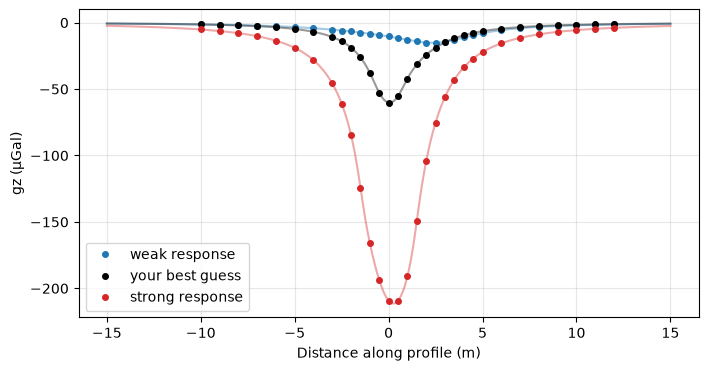

In [17]:
# ---- EDIT: design your station positions (m) ----
stations = np.unique(np.r_[
    np.arange(-10, -3, 1.0),
    np.arange(-3, 5.01, 0.5),
    np.arange(6, 12.01, 1.0),
])
# -------------------------------------------------

obs_st = np.c_[stations, np.zeros_like(stations)]
fig, ax = plt.subplots(figsize=(8, 4))
for k, p in cases.items():
    ax.plot(x_fine, gz_fine[k], color=colors[k], alpha=0.4)
    ax.plot(stations, model(p, obs_st), 'o', color=colors[k], ms=4, label=k)
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('gz (µGal)')
ax.legend()
ax.grid(alpha=0.3)

minutes_per_station = 4.5  # EDIT if you plan to read longer or repeat more
print(f"{len(stations)} stations -> about {len(stations) * minutes_per_station / 60:.1f} h"
      " of reading time, before base-station loops")

### Question 11: Plan A for October 20
Write a short plan that covers:
1. **Time budget:** In a 3 hour window, how many measurements with a single gravimeter can you take? We also need to survey in the locations with a DGPS (you can split into teams of course). Remember base station repeats! Leave time for setup and pack-up. Does your layout from Question 7 fit? If not, what do you cut, and why that?
2. **Reading time:** How long should each reading be, and how many repeats per station? Essentially, how long should we average values at each station?
3. **Drift control:** Where is your base station, and how often will you return to it?
4. **Other equipment:** Do we need to bring out anything else besides the gravimeter to perform our survey?
5. **Location:** Where should we perform the survey?

# Part 5: What if? Building a game plan

As you are becoming incresingly aware, field plans rarely survive contact with the field. Good crews decide ahead of time what they will do when something changes, so they can act quickly without wasting daylight or letting the gravimeter drift. For each scenario below, use the model to put a **number** on the effect where you can, then decide what you would do.

Use the sandbox cell below to test scenarios A to C. Change one thing at a time from your best guess.

               best guess: peak  -60.2 µGal, full width at half max 2.85 m
  Scenario A: deeper roof: peak  -40.6 µGal, full width at half max 4.55 m


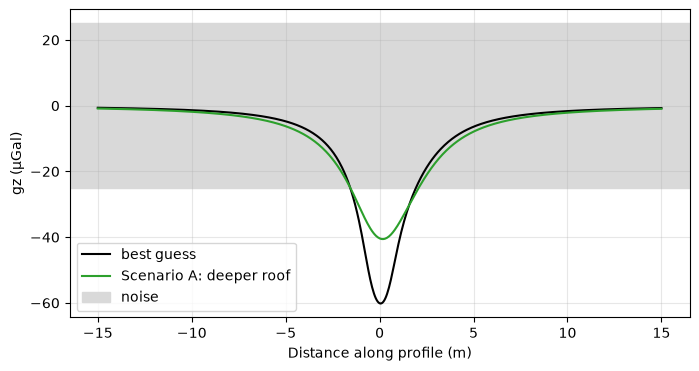

In [18]:
# ---- SANDBOX: copy your best guess and change something ----
scenario = dict(prior)
scenario['upper_roof'] = 1.2          # e.g., Scenario A: the tunnel is deeper than you thought
# scenario['host_density'] = 2.2      # e.g., Scenario B: the ground is saturated
label = 'Scenario A: deeper roof'
# -------------------------------------------------------------

g_s = model(scenario, obs_fine)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_fine, gz_fine['your best guess'], 'k', label='best guess')
ax.plot(x_fine, g_s, 'tab:green', label=label)
ax.axhspan(-noise, noise, color='0.85', label='noise')
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('gz (µGal)')
ax.legend()
ax.grid(alpha=0.3)
for k, g in [('best guess', gz_fine['your best guess']), (label, g_s)]:
    pk, w = peak_and_width(x_fine, g)
    print(f"{k:>25}: peak {pk:6.1f} µGal, full width at half max {w:4.2f} m")

### Question 12: Scenarios
Answer each in a few sentences (you don't need to be verbose here), with a number from the sandbox where it applies.

**A. The tunnel is deeper than you guessed.** On October 6 we find the upper tunnel's roof is 1.2 m down, not the value you picked. What happens to the peak and width? Does your Plan A line still capture the anomaly? What changes?

**B. It rains on October 18,19, or 20.** Water fills pore space in the soil. A saturated soil's density is roughly ρ_sat = ρ_dry + φ·ρ_water, where φ is porosity (try φ = 0.3). How much does the host density change? Does that make the anomaly bigger or smaller? Does this change your game plan?

**C. We lose an hour.** A gravimeter battery dies, lightning strikes, or setup takes longer than planned, and you have 2 hours instead of Which stations do you cut first, and which do you keep? Why?

**D. The site is busy.** An event is set up on Kafadar Commons (this happened in 2025) with music and heavy foot traffic, or the manhole sits right on your planned line. What do you change?


# Part 6: After the tour (complete after October 6)

## Tunnel tour data sheet (bring to the tour)
Copy this into your field notebook before the tour. Record every measurement with units, what you measured it with, and an estimate of its uncertainty.

* Width and floor-to-ceiling height of **both** tunnels, and wall thickness (if visible)
* Depth from the ground surface to each tunnel roof. How will you determine this from inside? (Hint: the access shaft.)
* The horizontal offset between the two tunnels
* Pipe sizes and anything else that takes up space inside the tunnels
* Where this tunnel section sits relative to landmarks above ground (manhole, building corners, sidewalk edges)
* A labeled sketch of the cross-section

### Question 13: Update your model
Enter what we measured on the tour, then run the cell. It plots your pre-tour best guess and the measured tunnel, with a gray band for the range of host densities you chose in Question 4 (the one thing the tour cannot tell us).

 pre-tour guess: peak  -60.2 µGal, full width at half max 2.85 m
       measured: peak  -75.3 µGal, full width at half max 3.75 m
Measured tunnel, host density 1.1 to 2.6 g/cc: peak -103 to -44 µGal


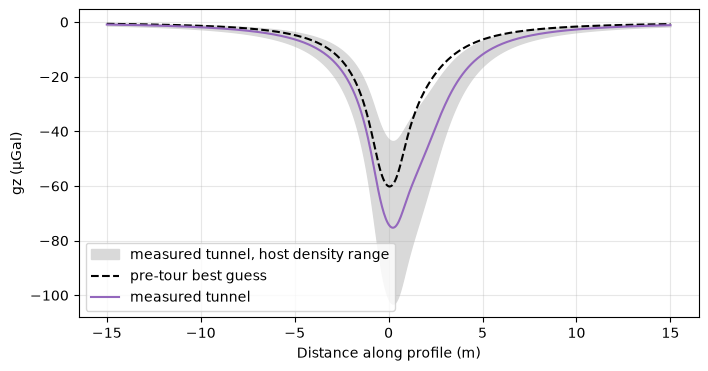

In [19]:
# ---- EDIT: measured on October 6 ----
measured = dict(prior)
measured.update({
    'upper_x': 0.0, 'upper_width': 1.4, 'upper_height': 1.9, 'upper_roof': 0.4,
    'lower_x': 1.5, 'lower_width': 1.7, 'lower_height': 1.6, 'lower_roof': 1.2,
})
host_range = ranges['host_density']   # from Question 4
# -------------------------------------

g_meas = model(measured, obs_fine)
g_lo = model(dict(measured, host_density=host_range[0]), obs_fine)
g_hi = model(dict(measured, host_density=host_range[1]), obs_fine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_fine, g_lo, g_hi, color='0.85', label='measured tunnel, host density range')
ax.plot(x_fine, gz_fine['your best guess'], 'k--', label='pre-tour best guess')
ax.plot(x_fine, g_meas, 'tab:purple', label='measured tunnel')
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('gz (µGal)')
ax.legend()
ax.grid(alpha=0.3)

for k, g in [('pre-tour guess', gz_fine['your best guess']), ('measured', g_meas)]:
    pk, w = peak_and_width(x_fine, g)
    print(f"{k:>15}: peak {pk:6.1f} µGal, full width at half max {w:4.2f} m")
print(f"Measured tunnel, host density {host_range[0]} to {host_range[1]} g/cc: "
      f"peak {g_hi.min():.0f} to {g_lo.min():.0f} µGal")

### Question 14: Final plan for October 20
1. Compare your pre-tour guess (Question 5) with the measurements. Which parameter were you furthest off on, and did Question 7 say it mattered?
2. **Your prediction:** the peak anomaly and full width at half max you expect on October 20, as a range, from the cell above. In Lab 6 you will compare this with the data and we'll see if density is consistent across the survey area!

# Deliverables
Submit a copy of this notebook with all questions answered in markdown cells, with figures supporting your answers. This does not need to be a formal report, but your answers should be easy for someone else to find.

**Note:** Widget states are not saved with the notebook. If you settle on a geometry in a widget, write the final vertices and density contrast into a code cell so your result can be reproduced.